In [1]:
import matplotlib.pyplot as plt
import cv2
import random
import os
from glob import glob
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, Flatten, Conv2D
from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import model_from_json
from tensorflow.keras.utils import to_categorical 
import tensorflow as tf

from PIL import Image, ImageTk
import tkinter as tk
from tkinter import filedialog

img_size = 48
batch_size = 64
epochs = 30




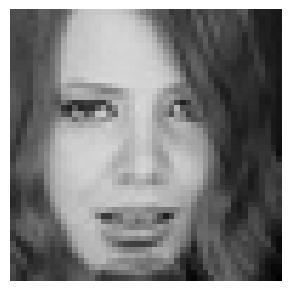

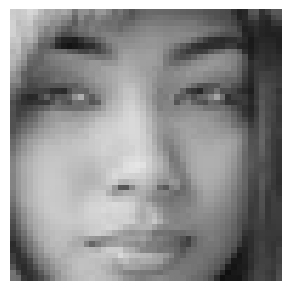

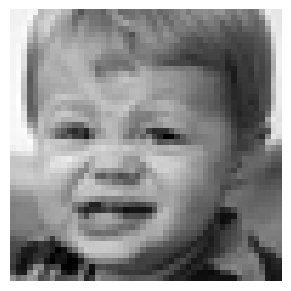

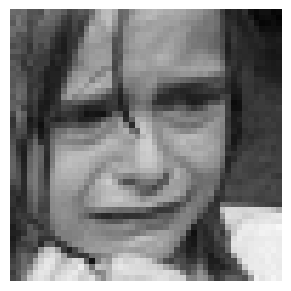

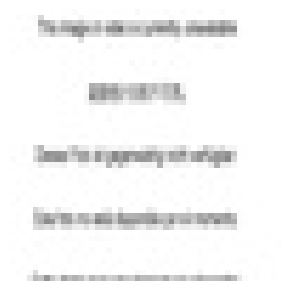

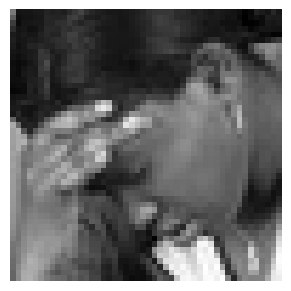

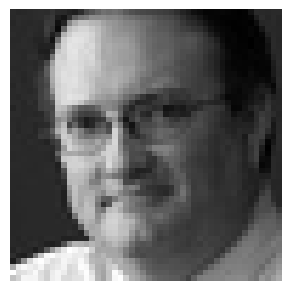

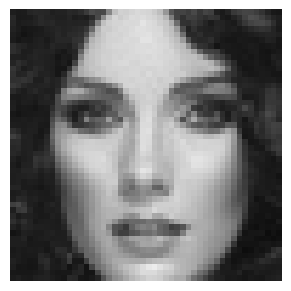

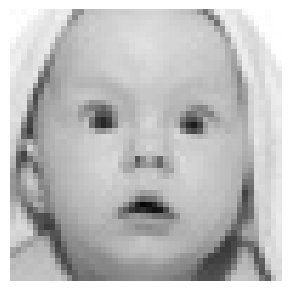

In [2]:
images=glob("train/**/**")
for i in range (9):
    image=random.choice(images)
    plt.figure(figsize=(12,12))
    plt.subplot(331+i)
    plt.imshow(cv2.imread(image));plt.axis('off')

In [3]:
def convolution(input_tensor, filters, kernel_size):
    x = Conv2D(filters=filters, kernel_size=kernel_size, padding="same")(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    return x

In [4]:
def dense_f(input_tensor, nodes):
    x = Dense(nodes)(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)
    return x

In [5]:
def model_fer(input_shape):
    inputs = Input(input_shape)
    x = convolution(inputs, 32, (3, 3))
    x = convolution(x, 64, (3, 3))
    x = Flatten()(x)
    x = dense_f(x, 128)
    x = dense_f(x, 64)
    outputs = Dense(7, activation="softmax")(x)

    model = Model(inputs, outputs)
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [7]:
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen_val = ImageDataGenerator(rescale=1./255)

train_generator = datagen_train.flow_from_directory(
    r"C:\Users\ramol\Downloads\emotion_detection\train",
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

validation_generator = datagen_val.flow_from_directory(
    r"C:\Users\ramol\Downloads\emotion_detection\test",
    target_size=(img_size, img_size),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [8]:
model = model_fer((48, 48, 1))
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 48, 48, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 48, 48, 32)       128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 48, 48, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 24, 24, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 24, 24, 32)        0     

In [9]:
steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = validation_generator.n // validation_generator.batch_size

checkpoint = ModelCheckpoint("model_weights.h5", monitor='val_accuracy', save_weights_only=True, mode='max', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

callbacks = [checkpoint, reduce_lr, early_stop]

In [10]:

history = model.fit( 
    
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)



Epoch 1/30
448/448 [==============================] - ETA: 0s - loss: 1.8228 - accuracy: 0.2731
Epoch 1: saving model to model_weights.h5
448/448 [==============================] - 779s 2s/step - loss: 1.8228 - accuracy: 0.2731 - val_loss: 1.7839 - val_accuracy: 0.2712 - lr: 0.0010
Epoch 2/30
448/448 [==============================] - ETA: 0s - loss: 1.6594 - accuracy: 0.3425
Epoch 2: saving model to model_weights.h5
448/448 [==============================] - 755s 2s/step - loss: 1.6594 - accuracy: 0.3425 - val_loss: 1.5703 - val_accuracy: 0.4057 - lr: 0.0010
Epoch 3/30
448/448 [==============================] - ETA: 0s - loss: 1.5837 - accuracy: 0.3838
Epoch 3: saving model to model_weights.h5
448/448 [==============================] - 612s 1s/step - loss: 1.5837 - accuracy: 0.3838 - val_loss: 1.4664 - val_accuracy: 0.4355 - lr: 0.0010
Epoch 4/30
448/448 [==============================] - ETA: 0s - loss: 1.5317 - accuracy: 0.4056
Epoch 4: saving model to model_weights.h5
448/448 [====

In [11]:
model = model_fer((48, 48, 1))
model.summary()

steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = validation_generator.n // validation_generator.batch_size

checkpoint = ModelCheckpoint("model_weights.h5", monitor='val_accuracy', save_weights_only=True, mode='max', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

callbacks = [checkpoint, reduce_lr, early_stop]

history = model.fit( 
    
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)


Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 48, 48, 1)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 48, 48, 32)        320       
                                                                 
 batch_normalization_4 (Batc  (None, 48, 48, 32)       128       
 hNormalization)                                                 
                                                                 
 activation_4 (Activation)   (None, 48, 48, 32)        0         
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 24, 24, 32)       0         
 2D)                                                             
                                                                 
 dropout_4 (Dropout)         (None, 24, 24, 32)        0   

In [12]:
model_json = model.to_json()
with open("model_a.json", "w") as json_file:
    json_file.write(model_json)


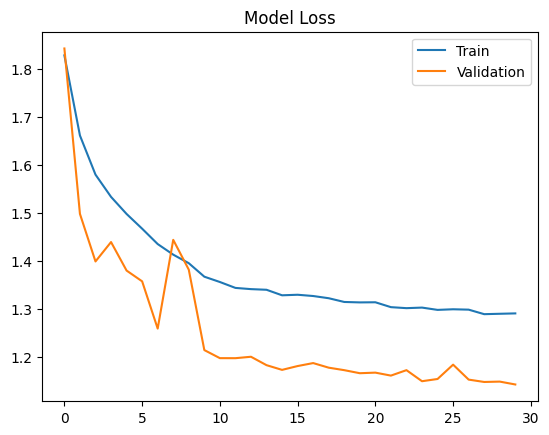

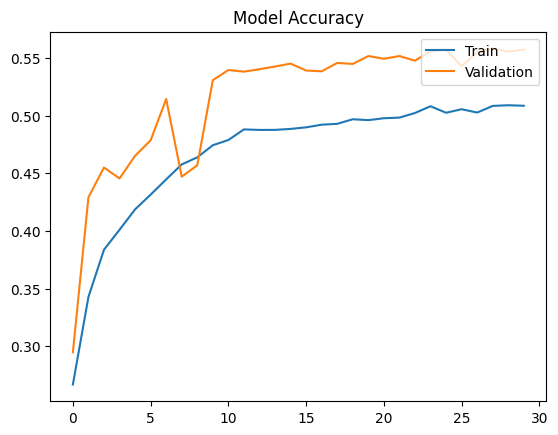

In [13]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


113/113 [==============================] - 15s 127ms/step


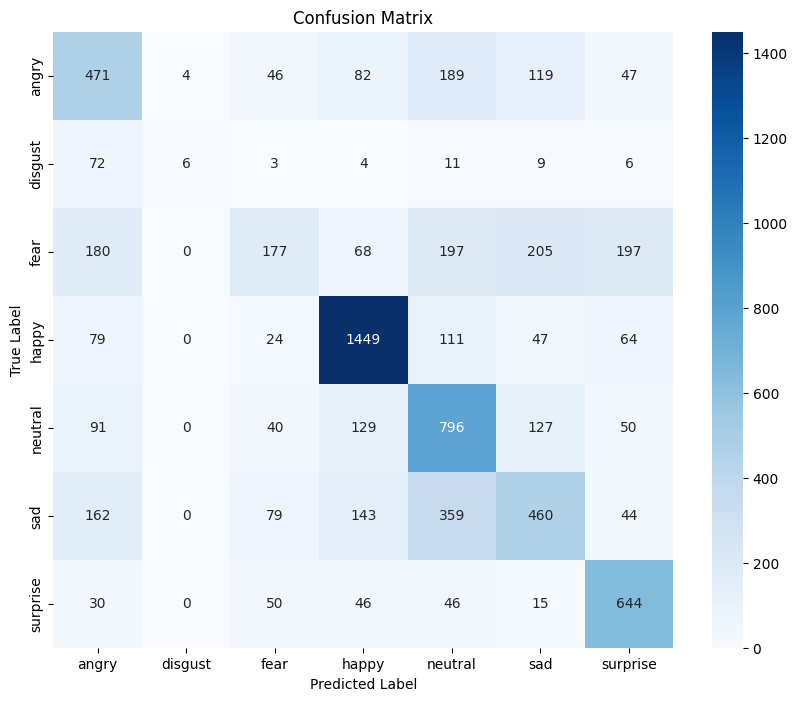

Classification Report:

              precision    recall  f1-score   support

       angry       0.43      0.49      0.46       958
     disgust       0.60      0.05      0.10       111
        fear       0.42      0.17      0.25      1024
       happy       0.75      0.82      0.78      1774
     neutral       0.47      0.65      0.54      1233
         sad       0.47      0.37      0.41      1247
    surprise       0.61      0.77      0.68       831

    accuracy                           0.56      7178
   macro avg       0.54      0.47      0.46      7178
weighted avg       0.55      0.56      0.54      7178



In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
Y_pred = model.predict(validation_generator, validation_steps + 1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes

# Get class labels
class_labels = list(validation_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n")
print(report)


In [20]:

import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import cv2
import numpy as np
from keras.models import model_from_json

# ------------------ Load Emotion Detection Model ------------------

class FacialExpressionModel:
    def __init__(self, model_json_file, model_weights_file):
        with open(model_json_file, "r") as json_file:
            loaded_model_json = json_file.read()
            self.model = model_from_json(loaded_model_json)
        self.model.load_weights(model_weights_file)

    def predict(self, img):
        return self.model.predict(img)

# ------------------ Global Setup ------------------

EMOTIONS_LIST = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]
facec = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
model = FacialExpressionModel("model_a.json", "model_weights.h5")

# ------------------ GUI Logic ------------------

def upload_image():
    file_path = filedialog.askopenfilename(filetypes=[("Image files", "*.jpg *.png *.jpeg")])
    if not file_path:
        return

    # Load and display image
    img = cv2.imread(file_path)
    process_image(img)

def process_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = facec.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(30, 30))

    if len(faces) > 0:
        for (x, y, w, h) in faces:
            roi = gray[y:y+h, x:x+w]
            roi = cv2.resize(roi, (48, 48))
            roi = roi.astype("float32") / 255.0
            roi = roi.reshape(1, 48, 48, 1)

            pred = model.predict(roi)
            emotion = EMOTIONS_LIST[np.argmax(pred)]

            # Draw rectangle and emotion label
            cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(image, emotion, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX,
                        0.9, (36, 255, 12), 2)

            result_label.config(text=f"Detected Emotion: {emotion}")

    else:
        result_label.config(text="No face detected.")

    # Show the processed image
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(image_rgb)
    img_resized = img_pil.resize((300, 300))
    img_tk = ImageTk.PhotoImage(img_resized)

    panel.config(image=img_tk)
    panel.image = img_tk

# ------------------ GUI Layout ------------------

root = tk.Tk()
root.title("Facial Emotion Detector")
root.configure(bg='white')

panel = tk.Label(root, bg='white')
panel.pack(pady=10)

result_label = tk.Label(root, text="Upload an image to detect emotion", font=("Arial", 14), bg='white')
result_label.pack(pady=5)

upload_button = tk.Button(root, text="Upload Image", command=upload_image)
upload_button.pack()

root.mainloop()


1/1 [==============================] - 1s 617ms/step


In [22]:
for i in range(len(model.model.layers)):
    if 'conv2d' not in model.model.layers[i].name:
        continue
    filters, biases = model.model.layers[i].get_weights()
    print("Layer number:", i, model.model.layers[i].name, "Filter shape:", filters.shape)



Layer number: 1 conv2d_2 Filter shape: (3, 3, 1, 32)
Layer number: 6 conv2d_3 Filter shape: (3, 3, 32, 64)


In [24]:
filters,bias=model.model.layers[1].get_weights()

In [25]:
f_min,f_max=filters.min(),filters.max()
filters=(filters-f_min)/(f_max-f_min)

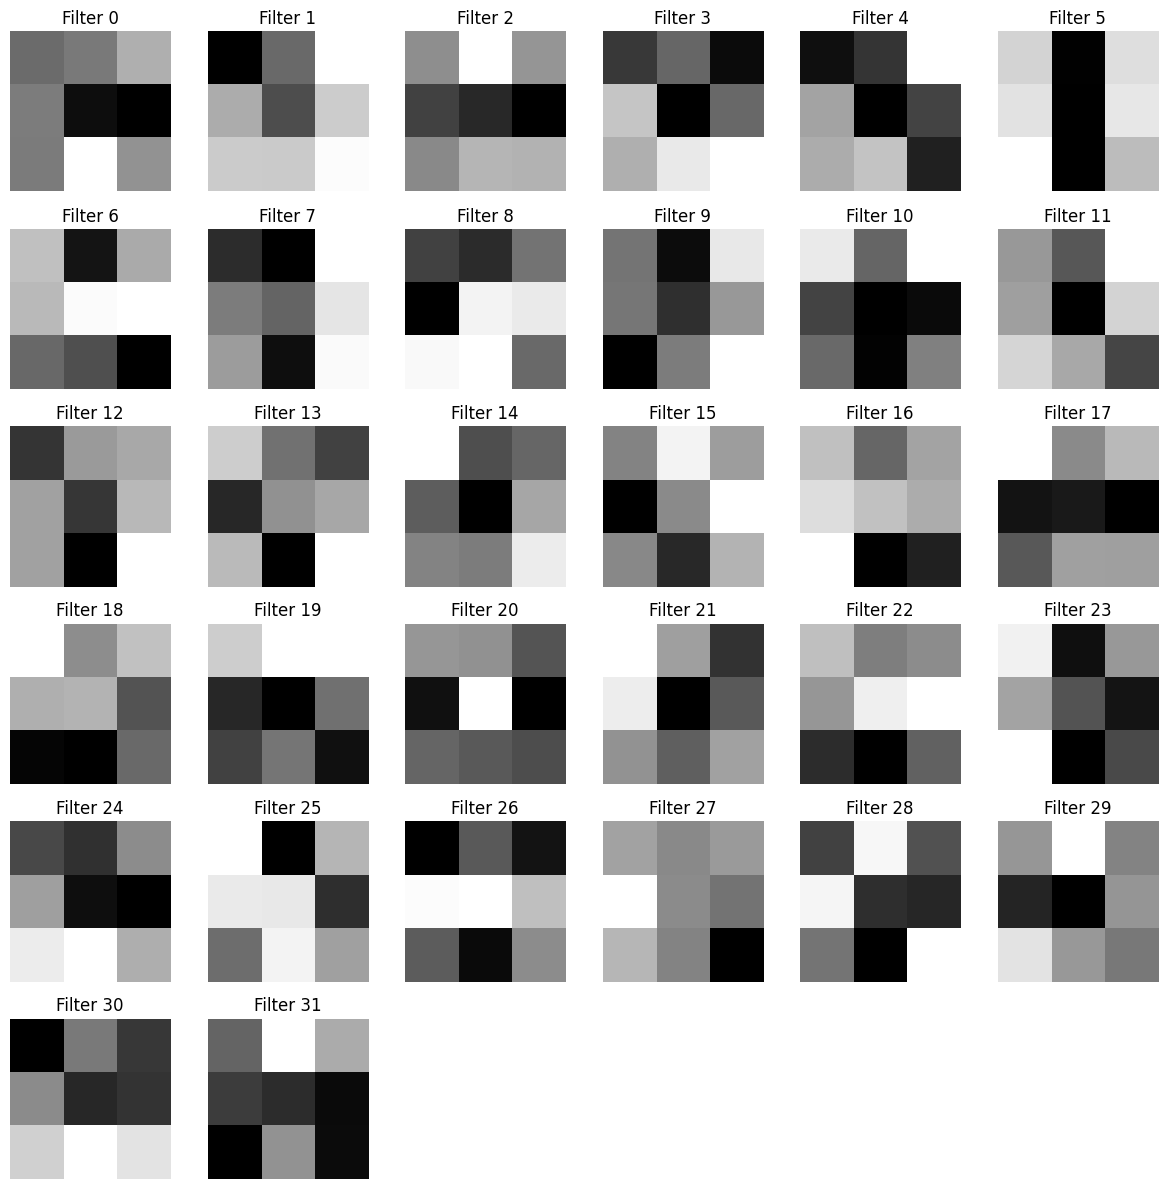

In [26]:
n_filters = filters.shape[3]
n_columns = 6  # How many filters per row
ix = 1

plt.figure(figsize=(12, 12))
for i in range(n_filters):
    # If grayscale, input channel = 1
    f = filters[:, :, 0, i]
    plt.subplot(n_filters // n_columns + 1, n_columns, ix)
    plt.imshow(f, cmap='gray')
    plt.axis('off')
    plt.title(f'Filter {i}')
    ix += 1

plt.tight_layout()
plt.show()

In [29]:
model=Model(inputs=model.model.inputs,outputs=model.model.layers[1].output)

In [31]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
image=load_img(r"C:\Users\ramol\OneDrive\Documents\New folder\image\download.jpeg",target_size=(48,48),color_mode='grayscale')
image=img_to_array(image)
image=np.expand_dims(image,axis=0)
image = image / 255.0


1/1 [==============================] - 0s 129ms/step


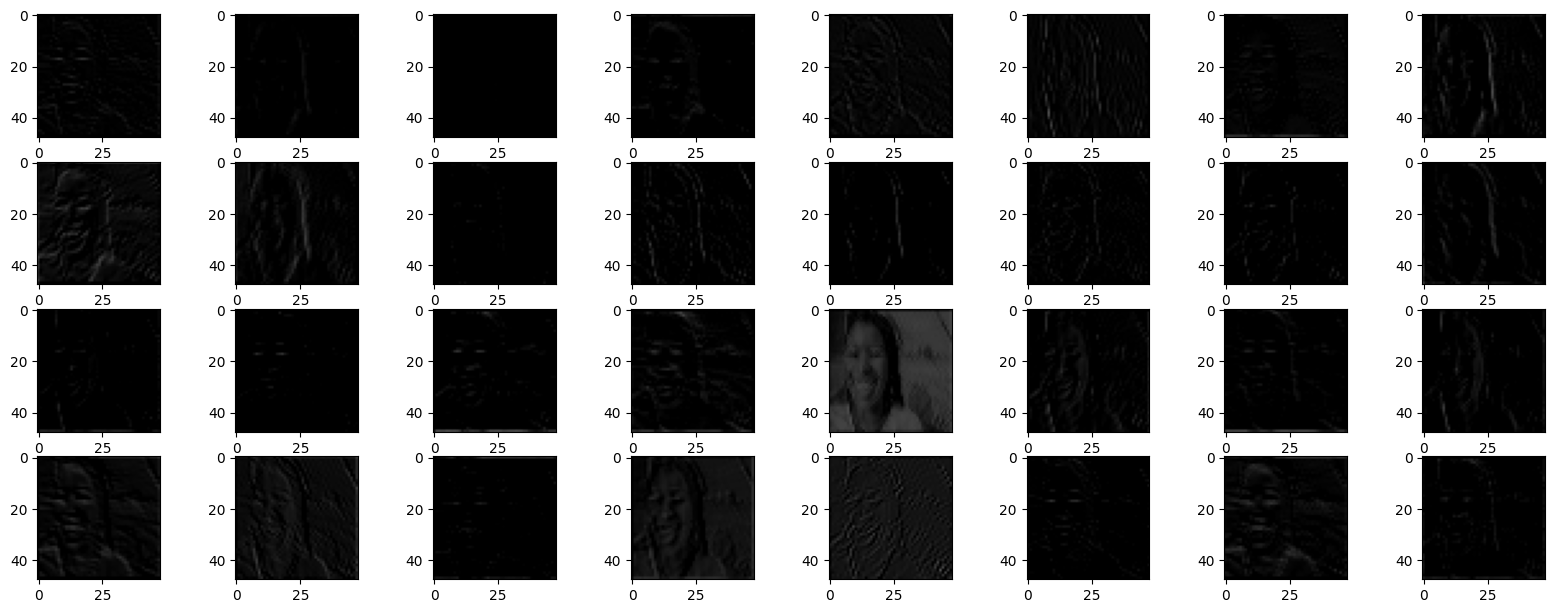

In [32]:
features = model.predict(image)
fig = plt.figure(figsize=(20, 15))
for i in range(1, features.shape[3] + 1):
    plt.subplot(8, 8, i)
    feature_map = features[0, :, :, i - 1]
    plt.imshow(feature_map, cmap='gray', vmin=0, vmax=1)  

plt.show()